# Deeper analysis: early-warning classifier, dropouts, Maths vs Portuguese

This notebook follows up on the "next steps" from `01_eda_and_baseline.ipynb`:

1. **Classification:** pass/fail early-warning model, evaluated with recall and precision
2. **Zero grades:** how much do the likely dropouts distort the models?
3. **Maths:** repeat the analysis on `student-mat.csv`
4. **Merging both subjects:** the same students in Portuguese and Maths
5. **Better model:** gradient boosting, hyperparameter tuning and SHAP
6. Summary

All models use **background information only** (no `G1`/`G2`). This is the early-warning scenario, where the model is meant to be used at the start of the school year.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score, confusion_matrix,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_val_predict,
                                     cross_validate)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=120)

por = pd.read_csv(RAW / "student-por.csv", sep=";")
mat = pd.read_csv(RAW / "student-mat.csv", sep=";")
GRADES = ["G1", "G2", "G3"]
SEED = 42

In [2]:
def preprocessor(X, dense=False, scale=True):
    """Scale numeric columns and one-hot encode categoricals.
    Tree models don't need scaling, and unscaled values are easier to read in SHAP plots."""
    num = X.select_dtypes("number").columns
    cat = X.select_dtypes("object").columns
    return ColumnTransformer([
        ("num", StandardScaler() if scale else "passthrough", num),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=not dense), cat),
    ], verbose_feature_names_out=False)

def early_warning_data(df):
    """Background features only, and target = 1 if the student fails (G3 < 10)."""
    return df.drop(columns=GRADES), (df["G3"] < 10).astype(int)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

## 1. Early-warning classifier (Portuguese)

The target becomes **`fail = G3 < 10`**. Two points matter here:
- **Classes are imbalanced:** only ~15% of students fail. Accuracy would be misleading, because a model that predicts "pass" for everyone already gets 85% right.
- **Errors have different costs:** missing an at-risk student (false negative) is worse than a false alarm (false positive), which only costs a teacher's attention. So we focus on **recall** (share of failing students we catch) and accept lower **precision** (share of flagged students who actually fail).

We compare logistic regression and a random forest, both with `class_weight="balanced"`. Probabilities come from 5-fold cross-validation, so every student is scored by a model that never saw them.

In [3]:
X, y = early_warning_data(por)
print(f"Fail rate: {y.mean():.1%} ({y.sum()} of {len(y)} students)")

classifiers = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random forest": RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                            class_weight="balanced", random_state=SEED, n_jobs=-1),
}

proba = {}
rows = []
for name, clf in classifiers.items():
    p = cross_val_predict(Pipeline([("prep", preprocessor(X)), ("model", clf)]), X, y,
                          cv=cv_clf, method="predict_proba")[:, 1]
    proba[name] = p
    rows.append({"Model": name, "ROC AUC": roc_auc_score(y, p), "Avg. precision": average_precision_score(y, p),
                 "Recall @0.5": recall_score(y, p >= 0.5), "Precision @0.5": precision_score(y, p >= 0.5)})
print(f"(A random model would have an average precision of {y.mean():.2f})")
pd.DataFrame(rows).round(2)

Fail rate: 15.4% (100 of 649 students)


(A random model would have an average precision of 0.15)


,Model,ROC AUC,Avg. precision,Recall @0.5,Precision @0.5
0,Logistic regression,0.79,0.41,0.67,0.36
1,Random forest,0.84,0.49,0.40,0.56


Both models rank students far better than chance (ROC AUC ≈ 0.8). The random forest ranks slightly better, but at the default 0.5 threshold it is **too cautious**: it catches less than half of the failing students.

The 0.5 threshold is arbitrary. For an early-warning system we should **pick the threshold that gives the recall we need**. The precision–recall curve shows the trade-off:

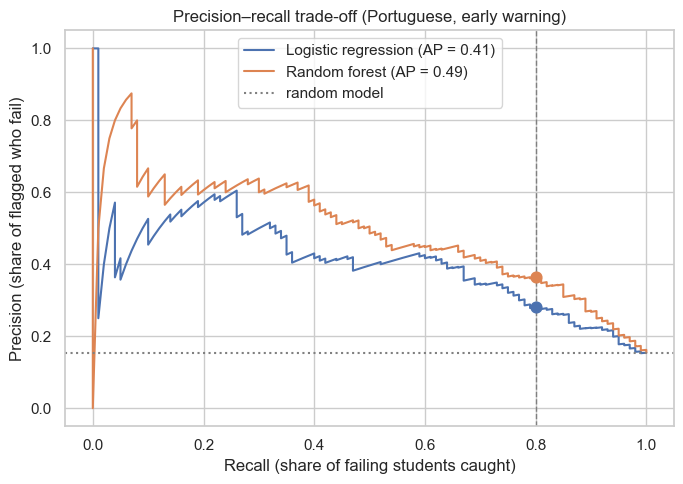

Logistic regression  threshold=0.27  recall=0.80  precision=0.28  flagged=285 students
Random forest        threshold=0.28  recall=0.80  precision=0.36  flagged=220 students


In [4]:
TARGET_RECALL = 0.80

fig, ax = plt.subplots(figsize=(7, 5))
chosen = {}
for name, p in proba.items():
    prec, rec, thr = precision_recall_curve(y, p)
    ax.plot(rec, prec, label=f"{name} (AP = {average_precision_score(y, p):.2f})")
    # highest threshold that still reaches the target recall
    ok = np.where(rec[:-1] >= TARGET_RECALL)[0]
    i = ok[-1]
    chosen[name] = thr[i]
    ax.scatter(rec[i], prec[i], s=60, zorder=3)
ax.axhline(y.mean(), color="grey", ls=":", label="random model")
ax.axvline(TARGET_RECALL, color="grey", ls="--", lw=1)
ax.set(xlabel="Recall (share of failing students caught)", ylabel="Precision (share of flagged who fail)",
       title="Precision–recall trade-off (Portuguese, early warning)")
ax.legend()
save_fig("06_precision_recall")
plt.show()

for name, t in chosen.items():
    p = proba[name]
    print(f"{name:20s} threshold={t:.2f}  recall={recall_score(y, p >= t):.2f}  "
          f"precision={precision_score(y, p >= t):.2f}  flagged={int((p >= t).sum())} students")

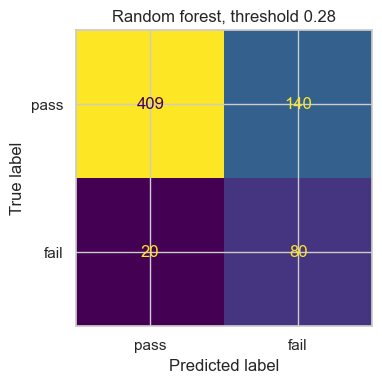

In [5]:
best = "Random forest"
pred = proba[best] >= chosen[best]
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y, pred), display_labels=["pass", "fail"]).plot(ax=ax, colorbar=False)
ax.set_title(f"{best}, threshold {chosen[best]:.2f}")
save_fig("07_confusion_matrix")
plt.show()

**How to read this in school terms:** to catch ~80% of the students who will fail, the school has to flag a much larger group, and only about 1 in 3 of the flagged students actually fails.
That is still useful: it narrows attention from the whole cohort to a smaller list, and the "false alarms" are mostly borderline students who would also benefit from support.

⚠️ The threshold was chosen on the same cross-validated predictions we report, so these numbers are slightly optimistic. In production you would choose it on a separate validation set, or on the previous year's cohort.

## 2. Zero grades: likely dropouts

Notebook 01 showed that students with `G3 = 0` look like mid-year dropouts. Let's check whether the same pattern holds in Maths, and how much these cases hurt the regression models.

In [6]:
def zero_profile(df):
    z = df[df["G3"] == 0]
    return pd.Series({
        "students": len(df), "G3 = 0": len(z), "share": len(z) / len(df),
        "zero absences (among G3=0)": (z["absences"] == 0).mean(),
        "zero absences (others)": (df.loc[df["G3"] > 0, "absences"] == 0).mean(),
        "G2 = 0 (among G3=0)": (z["G2"] == 0).mean(),
    })

pd.DataFrame({"Portuguese": zero_profile(por), "Maths": zero_profile(mat)}).round(2)

,Portuguese,Maths
students,649.00,395.00
G3 = 0,15.00,38.00
share,0.02,0.10
zero absences (among G3=0),1.00,1.00
zero absences (others),0.36,0.22
G2 = 0 (among G3=0),0.47,0.34


The pattern is even clearer in Maths, which has many more zeros (~10% of students vs ~2%). **Every** student with a final grade of 0 has zero recorded absences, compared with only 36% (Portuguese) and 22% (Maths) of the other students.
Many also have `G2 = 0` already (about half in Portuguese, a third in Maths), so they were gone by the 2nd term. The rest left later in the year.

These students are not "very bad at the subject". They are a **different outcome** (leaving school), and mixing them into a grade regression adds noise:

In [7]:
def ridge_scores(df, with_grades):
    X = df.drop(columns=["G3"] if with_grades else GRADES)
    model = Pipeline([("prep", preprocessor(X)), ("model", RidgeCV(alphas=np.logspace(-2, 3, 20)))])
    s = cross_validate(model, X, df["G3"], cv=cv_reg, scoring=["neg_mean_absolute_error", "r2"])
    return -s["test_neg_mean_absolute_error"].mean(), s["test_r2"].mean()

rows = []
for subject, df in [("Portuguese", por), ("Maths", mat)]:
    for label, data in [("all students", df), ("without G3 = 0", df[df["G3"] > 0])]:
        for scenario, wg in [("early warning", False), ("mid-year (G1, G2)", True)]:
            mae, r2 = ridge_scores(data, wg)
            rows.append({"Subject": subject, "Data": label, "Scenario": scenario, "MAE": mae, "R²": r2})
pd.DataFrame(rows).round(2).pivot_table(index=["Subject", "Scenario"], columns="Data", values=["MAE", "R²"])

MAE                          R²  \
Data                         all students without G3 = 0 all students   
Subject    Scenario                                                     
Maths      early warning             3.26           2.37         0.12   
           mid-year (G1, G2)         1.33           0.68         0.80   
Portuguese early warning             1.98           1.77         0.26   
           mid-year (G1, G2)         0.83           0.68         0.84   

                                             
Data                         without G3 = 0  
Subject    Scenario                          
Maths      early warning               0.18  
           mid-year (G1, G2)           0.92  
Portuguese early warning               0.30  
           mid-year (G1, G2)           0.88

Removing the zeros improves every model, and dramatically so in Maths: the mid-year MAE roughly halves.
The lesson: **one target was hiding two problems**, predicting the grade and predicting dropout. In a real system they should be modelled separately. Dropout is arguably the more important of the two, but with only 15 + 38 cases there is too little data here to model it reliably.

## 3. Maths vs Portuguese

Same analysis, other subject. Maths is known to be harder, so let's see how the picture changes.

In [8]:
def summary(df):
    X, y = early_warning_data(df)
    rf = Pipeline([("prep", preprocessor(X)),
                   ("model", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                                    class_weight="balanced", random_state=SEED, n_jobs=-1))])
    p = cross_val_predict(rf, X, y, cv=cv_clf, method="predict_proba")[:, 1]
    return pd.Series({
        "students": len(df), "mean G3": df["G3"].mean(), "fail rate": y.mean(),
        "early-warning ROC AUC": roc_auc_score(y, p), "early-warning avg. precision": average_precision_score(y, p),
    })

pd.DataFrame({"Portuguese": summary(por), "Maths": summary(mat)}).round(2)

,Portuguese,Maths
students,649.00,395.00
mean G3,11.91,10.42
fail rate,0.15,0.33
early-warning ROC AUC,0.84,0.69
early-warning avg. precision,0.49,0.55


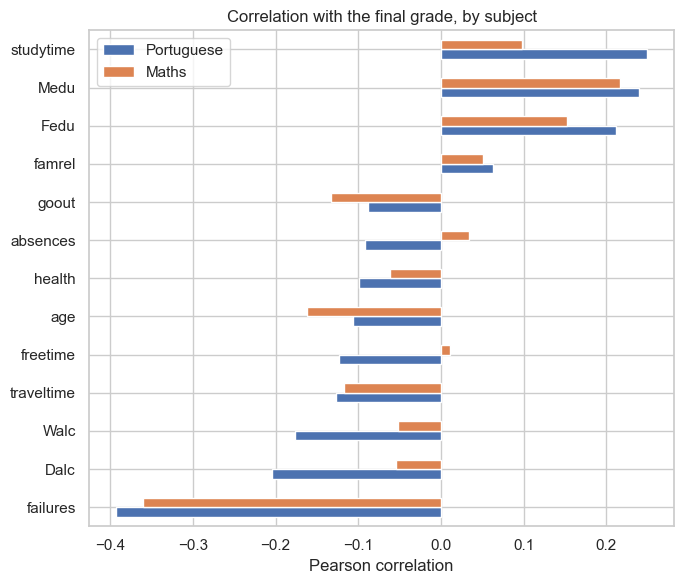

In [9]:
num = [c for c in por.select_dtypes("number").columns if c not in GRADES]
corr = pd.DataFrame({
    "Portuguese": por[num + ["G3"]].corr()["G3"].drop("G3"),
    "Maths": mat[num + ["G3"]].corr()["G3"].drop("G3"),
}).sort_values("Portuguese")

ax = corr.plot.barh(figsize=(7, 6))
ax.set(title="Correlation with the final grade, by subject", xlabel="Pearson correlation")
save_fig("08_correlations_by_subject")
plt.show()

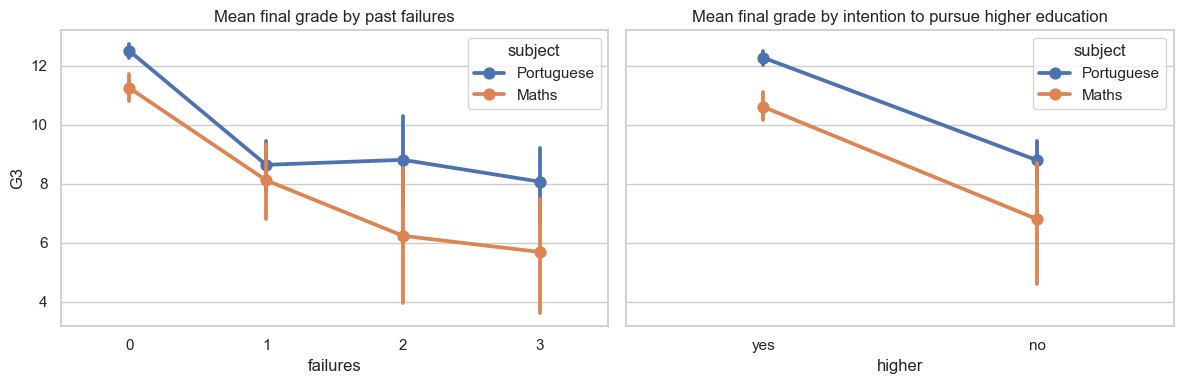

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
both = pd.concat([por.assign(subject="Portuguese"), mat.assign(subject="Maths")])
sns.pointplot(data=both, x="failures", y="G3", hue="subject", ax=axes[0], errorbar=("ci", 95))
axes[0].set_title("Mean final grade by past failures")
sns.pointplot(data=both, x="higher", y="G3", hue="subject", ax=axes[1], errorbar=("ci", 95))
axes[1].set_title("Mean final grade by intention to pursue higher education")
save_fig("09_subject_comparison")
plt.show()

**What changes in Maths**
- Twice the fail rate (~33% vs ~15%) and a lower mean grade.
- **Past failures** and **wanting to go to university** remain the key signals, and their effect is even larger in Maths.
- **Alcohol** almost disappears as a factor in Maths, while **age** and **going out** gain weight.
- The early-warning model is **weaker** in Maths (ROC AUC ≈ 0.69 vs 0.84). Background characteristics say less about who will fail Maths. Part of the reason is the large share of dropouts, which are hard to predict.
- Careful: average precision looks *higher* in Maths (0.55 vs 0.49), but only because failing is twice as common there (a random model would score 0.33 instead of 0.15). Average precision must always be compared against the base rate.

## 4. Same students, two subjects

The dataset authors note that **382 students** appear in both files. There is no student ID, so the match is made on 13 background attributes.

⚠️ This is an approximate match: a few students share the same combination of attributes (see the duplicate check below), so a small number of pairs may be mismatched.

In [11]:
KEYS = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
        "Mjob", "Fjob", "reason", "nursery", "internet"]
print("Duplicate key combinations: Maths", mat.duplicated(KEYS).sum(), "| Portuguese", por.duplicated(KEYS).sum())

both = pd.merge(mat, por, on=KEYS, suffixes=("_mat", "_por"))
print("Matched students:", len(both))
print(f"Correlation between Maths and Portuguese final grades: {both['G3_mat'].corr(both['G3_por']):.2f}")

Duplicate key combinations: Maths 4 | Portuguese 12
Matched students: 382
Correlation between Maths and Portuguese final grades: 0.48


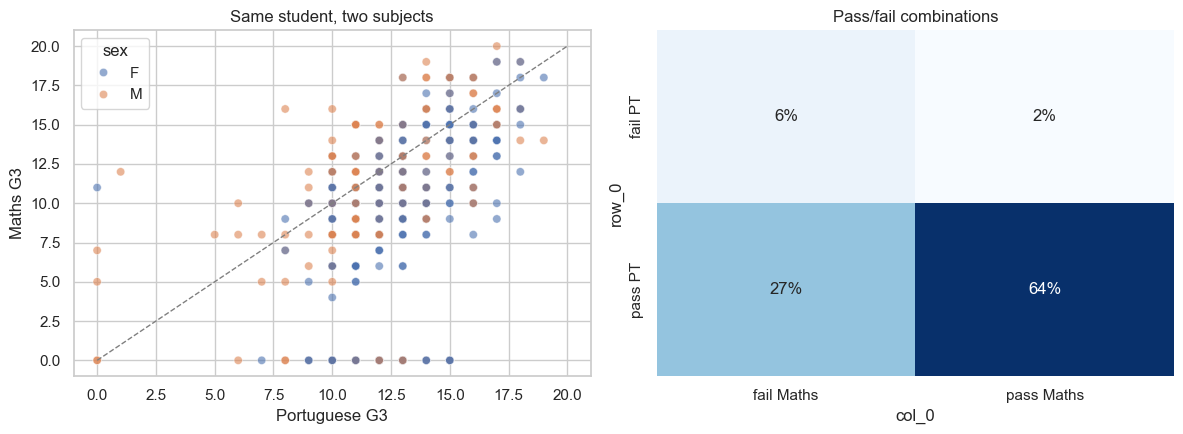

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(data=both, x="G3_por", y="G3_mat", hue="sex", alpha=0.6, ax=axes[0])
axes[0].plot([0, 20], [0, 20], color="grey", ls="--", lw=1)
axes[0].set(xlabel="Portuguese G3", ylabel="Maths G3", title="Same student, two subjects")

outcome = pd.crosstab(np.where(both["G3_por"] >= 10, "pass PT", "fail PT"),
                      np.where(both["G3_mat"] >= 10, "pass Maths", "fail Maths"), normalize=True)
sns.heatmap(outcome, annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Pass/fail combinations")
save_fig("10_maths_vs_portuguese")
plt.show()

In [13]:
both.groupby("sex")[["G3_mat", "G3_por"]].mean().round(2)

,G3_mat,G3_por
sex,,
F,9.84,13.09
M,10.98,11.90


**Findings**
- Grades in the two subjects are only **moderately correlated** (r ≈ 0.48). Doing well in one subject says something, but not everything, about the other.
- Failing **only Maths** is common (~27% of matched students), failing **only Portuguese** is rare (~2%). Almost everyone who fails Portuguese also fails Maths.
- **The gender gap reverses:** girls do better in Portuguese, boys do better in Maths. This matches the pattern seen in large-scale assessments such as PISA, and is a reminder that "student performance" is not a single trait.

## 5. Better model: gradient boosting, tuning and SHAP

We try `HistGradientBoostingClassifier`, tune a few hyperparameters with `GridSearchCV` (optimising average precision), and explain the model with **SHAP**.
SHAP values show, for each student, how much each feature pushed the predicted risk up or down.

In [14]:
X, y = early_warning_data(por)
pipe = Pipeline([
    ("prep", preprocessor(X, dense=True, scale=False)),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)),
])
grid = GridSearchCV(pipe, {
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [2, 3, None],
    "model__min_samples_leaf": [10, 30],
    "model__l2_regularization": [0.0, 1.0],
}, scoring="average_precision", cv=cv_clf, n_jobs=-1)
grid.fit(X, y)
print("Best parameters:", grid.best_params_)
print(f"Best CV average precision: {grid.best_score_:.3f}")

Best parameters: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 10}
Best CV average precision: 0.533


In [15]:
# Fair comparison: score the tuned model with the same CV predictions as the other models.
# (Strictly, tuning and evaluating on the same folds is slightly optimistic; nested CV would fix that.)
p_gb = cross_val_predict(grid.best_estimator_, X, y, cv=cv_clf, method="predict_proba")[:, 1]
proba["Gradient boosting (tuned)"] = p_gb
pd.DataFrame([{"Model": n, "ROC AUC": roc_auc_score(y, p), "Avg. precision": average_precision_score(y, p)}
              for n, p in proba.items()]).round(3)

,Model,ROC AUC,Avg. precision
0,Logistic regression,0.789,0.407
1,Random forest,0.835,0.494
2,Gradient boosting (tuned),0.808,0.463


Two lessons here:
- **The tuned gradient boosting does not beat the random forest.** With 649 students and a weak signal, the model choice matters less than the data. More students, or better features (attendance over time, previous year's grades), would help far more than a fancier algorithm. That is a useful, honest conclusion to report.
- **The grid search score is optimistic.** `GridSearchCV` reports the best of 24 combinations, and that maximum is biased upwards. Scored again with fresh predictions, the same model does noticeably worse. This is why tuning and final evaluation should use separate data (nested cross-validation or a hold-out set).

Even so, SHAP is a great way to *explain* any tree model, so let's use it:

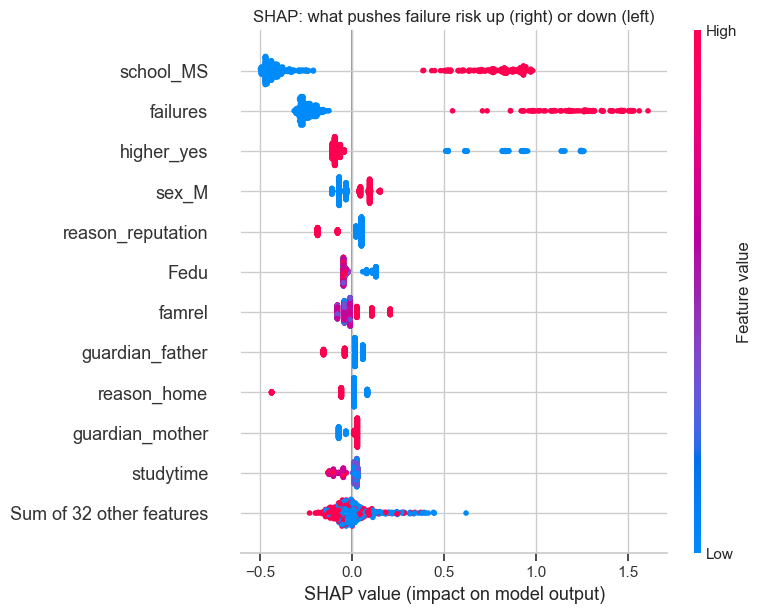

In [16]:
warnings.filterwarnings("ignore", message="IProgress not found")
import shap

model = grid.best_estimator_
X_enc = pd.DataFrame(model.named_steps["prep"].transform(X),
                     columns=model.named_steps["prep"].get_feature_names_out())
explainer = shap.TreeExplainer(model.named_steps["model"])
shap_values = explainer(X_enc)

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP: what pushes failure risk up (right) or down (left)")
save_fig("11_shap_beeswarm")
plt.show()

**How to read the plot:** each dot is a student. Red means a high value of the feature, blue a low one. Dots to the right **increase** the predicted risk of failing (values are in log-odds).
- Three features dominate: **school**, **past failures** and **wanting to go to university**. Everything else has a small effect.
- `school_MS` (red = attends MS) pushes risk up strongly. This model leans on the school more than the random forest did. Remember that "school" stands in for everything that differs between the two schools (location, intake, socio-economic background), not for teaching quality.
- Any past failure pushes risk sharply up. Not wanting to go to university (blue on `higher_yes`) does the same.
- Being male pushes risk up slightly, consistent with the gender gap in Portuguese seen in section 4.

The global picture matches notebook 01, but SHAP also explains **individual** predictions, which is what a teacher would need ("why is this student flagged?").

Student #506: predicted risk 91%, actual final grade G3 = 10


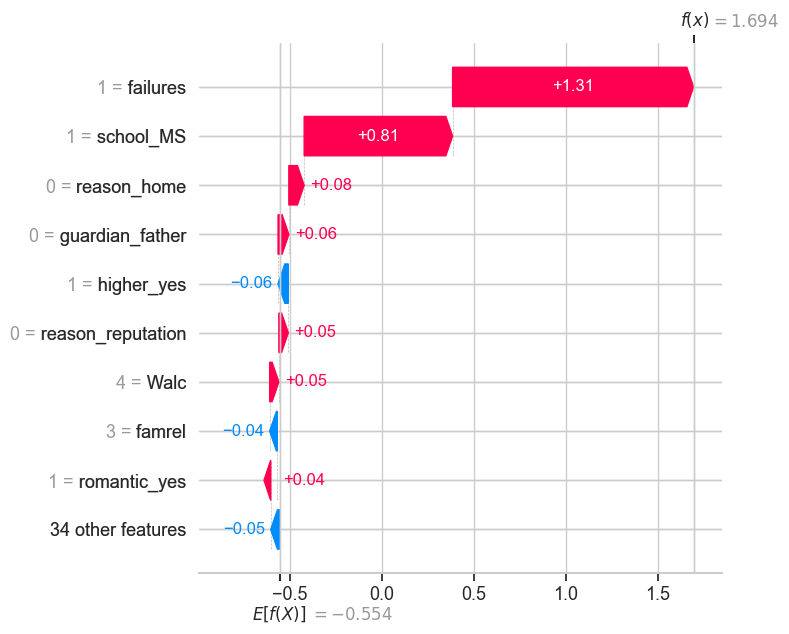

In [17]:
# Example: explain the student with the highest predicted risk
i = int(np.argmax(p_gb))
print(f"Student #{i}: predicted risk {p_gb[i]:.0%}, actual final grade G3 = {por.loc[i, 'G3']}")
shap.plots.waterfall(shap_values[i], max_display=10, show=False)
save_fig("12_shap_single_student")
plt.show()

The highest-risk student is flagged almost entirely because of **past failures** and **attending MS**. They ended up with exactly 10, the lowest passing grade.
So this is technically a "false alarm", but it is exactly the kind of borderline student an early-warning system should be flagging.

## 6. Summary

| Exercise | Main takeaway |
|---|---|
| Classification | An early-warning model can catch ~80% of failing students, at the cost of flagging a larger group (precision ≈ 0.35). The threshold matters more than the algorithm. |
| Zero grades | They are dropouts, not low grades (every one has zero recorded absences). Removing them improves all models, especially in Maths. Dropout should be its own target. |
| Maths | Fail rate doubles. Past failures and ambition matter even more; alcohol matters less. Background data predicts Maths failure less well. |
| Both subjects | Moderate correlation (r ≈ 0.48). Failing only Maths is common; the gender gap reverses between subjects. |
| Gradient boosting + SHAP | No gain over random forest on this small dataset, and the grid search score was optimistic. SHAP shows the school, past failures and ambition drive the predictions, and it explains individual flags. |

**Next:** the interactive dashboard is in `app/app.py` (run `streamlit run app/app.py`). The comparison with recent national exam data is a separate project.